In [5]:
!pip -q install geopandas geodatasets libpysal esda spreg contextily hdbscan

In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

import geodatasets

from libpysal.weights import Queen, KNN
from esda.moran import Moran
from esda.getisord import G_Local
from spreg import ML_Lag, ML_Error

import hdbscan

import warnings
warnings.filterwarnings("ignore")

In [7]:
# Load Chicago population geospatial dataset
path = geodatasets.get_path("geoda.chicago_commpop")

gdf = gpd.read_file(path)

print("Dataset shape:", gdf.shape)
print("\nColumns:")
print(gdf.columns.tolist())

gdf.head()

Extracting 'chicago_commpop/chicago_commpop.geojson' from '/root/.cache/geodatasets/chicago_commpop.zip' to '/root/.cache/geodatasets/chicago_commpop.zip.unzip'


Dataset shape: (77, 9)

Columns:
['community', 'NID', 'POP2010', 'POP2000', 'POPCH', 'POPPERCH', 'popplus', 'popneg', 'geometry']


,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [8]:
print(gdf.info())

print("\nCoordinate Reference System:")
print(gdf.crs)

print("\nNumber of communities:")
print(len(gdf))

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   community  77 non-null     object  
 1   NID        77 non-null     int32   
 2   POP2010    77 non-null     int32   
 3   POP2000    77 non-null     int32   
 4   POPCH      77 non-null     int32   
 5   POPPERCH   77 non-null     float64 
 6   popplus    77 non-null     int32   
 7   popneg     77 non-null     int32   
 8   geometry   77 non-null     geometry
dtypes: float64(1), geometry(1), int32(6), object(1)
memory usage: 3.7+ KB
None

Coordinate Reference System:
EPSG:4326

Number of communities:
77


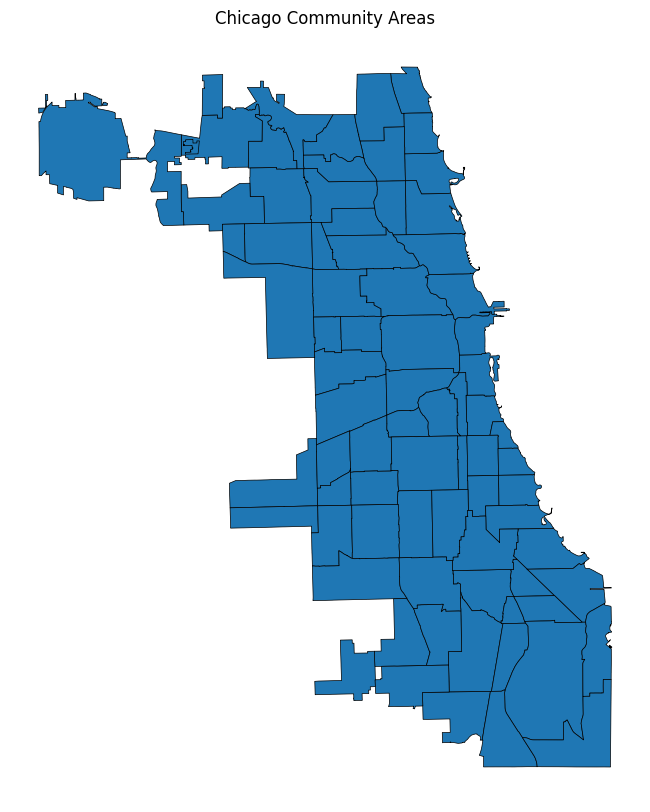

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Chicago Community Areas")
ax.set_axis_off()

plt.show()

In [10]:
print("Object type:", type(gdf))
print("Geometry type:")
print(gdf.geometry.geom_type.value_counts())

print("\nCRS:")
print(gdf.crs)

Object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Geometry type:
MultiPolygon    77
Name: count, dtype: int64

CRS:
EPSG:4326


In [11]:
# Create Queen contiguity spatial weights
w = Queen.from_dataframe(gdf)

# Row-standardize weights
w.transform = "R"

print("Number of spatial units:", w.n)
print("Number of neighbors for first 5 areas:")

for i in range(5):
    print(i, "->", w.neighbors[i])

Number of spatial units: 77
Number of neighbors for first 5 areas:
0 -> [33, 34, 3, 1]
1 -> [0, 3, 4]
2 -> [65, 34, 3, 6, 57, 58]
3 -> [0, 1, 34, 2, 4, 6, 7]
4 -> [1, 3, 6, 7]


In [12]:
y = gdf["POPPERCH"].values

moran = Moran(y, w)

print("Moran's I:", moran.I)
print("Expected I:", moran.EI)
print("Z-score:", moran.z_norm)
print("P-value:", moran.p_norm)

Moran's I: 0.30999371809986664
Expected I: -0.013157894736842105
Z-score: 4.492820856500814
P-value: 7.028590733570267e-06


In [13]:
if moran.p_norm < 0.05:
    if moran.I > 0:
        print("Result: Significant positive spatial autocorrelation.")
        print("Similar population-change values are spatially clustered.")
    else:
        print("Result: Significant negative spatial autocorrelation.")
        print("Nearby regions tend to have dissimilar values.")
else:
    print("Result: No statistically significant spatial autocorrelation.")

Result: Significant positive spatial autocorrelation.
Similar population-change values are spatially clustered.


In [14]:
# Local Getis-Ord statistic
g_local = G_Local(y, w)

gdf["Gi_ZScore"] = g_local.Zs

gdf[["community", "POPPERCH", "Gi_ZScore"]].head()

,community,POPPERCH,Gi_ZScore
0,DOUGLAS,-31.099358,-1.578712
1,OAKLAND,-3.142390,0.682956
2,FULLER PARK,-15.906433,0.361801
3,GRAND BOULEVARD,-21.698922,0.300720
4,KENWOOD,-2.842673,0.463294


In [15]:
def hotspot(row):
    if row["Gi_ZScore"] > 1.96:
        return "Hotspot"
    elif row["Gi_ZScore"] < -1.96:
        return "Coldspot"
    else:
        return "Not Significant"


gdf["Hotspot"] = gdf.apply(hotspot, axis=1)

print(gdf["Hotspot"].value_counts())

Hotspot
Not Significant    76
Coldspot            1
Name: count, dtype: int64


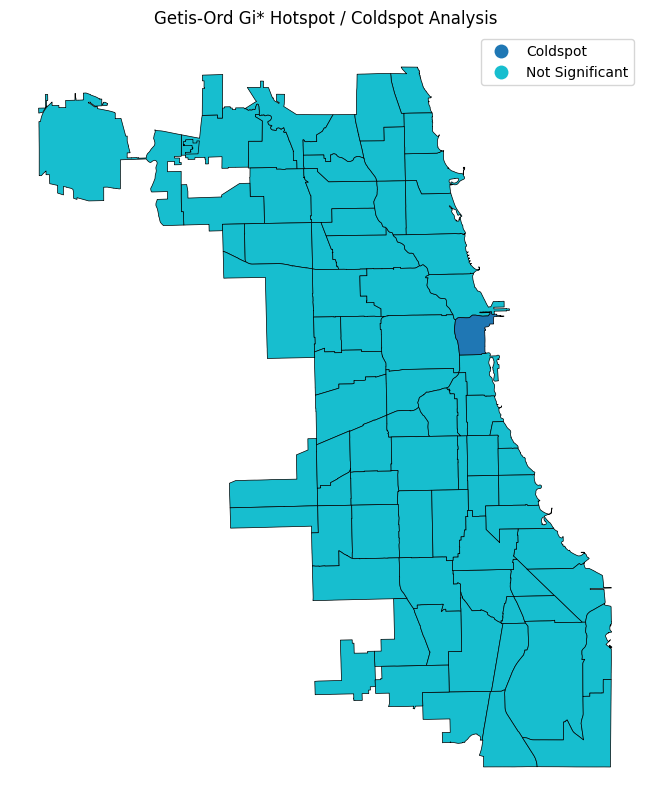

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Hotspot",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Getis-Ord Gi* Hotspot / Coldspot Analysis")
ax.set_axis_off()

plt.show()

In [17]:
# Project to a metric CRS before calculating centroids
gdf_projected = gdf.to_crs(epsg=26916)

gdf_projected["centroid"] = gdf_projected.geometry.centroid

gdf_projected["X"] = gdf_projected.centroid.x
gdf_projected["Y"] = gdf_projected.centroid.y

gdf_projected[["community", "X", "Y"]].head()

,community,X,Y
0,DOUGLAS,448630.408744,4.631655e+06
1,OAKLAND,449905.353655,4.630384e+06
2,FULLER PARK,447467.720439,4.628773e+06
3,GRAND BOULEVARD,448680.635952,4.629193e+06
4,KENWOOD,450477.971060,4.628733e+06


In [18]:
X = gdf_projected[["X", "Y"]]
y = gdf_projected["POPPERCH"]

# Degree 2 polynomial
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

gdf_projected["Trend_Prediction"] = model.predict(X_poly)

print("R² Score:", model.score(X_poly, y))

R² Score: 0.13099572293994644


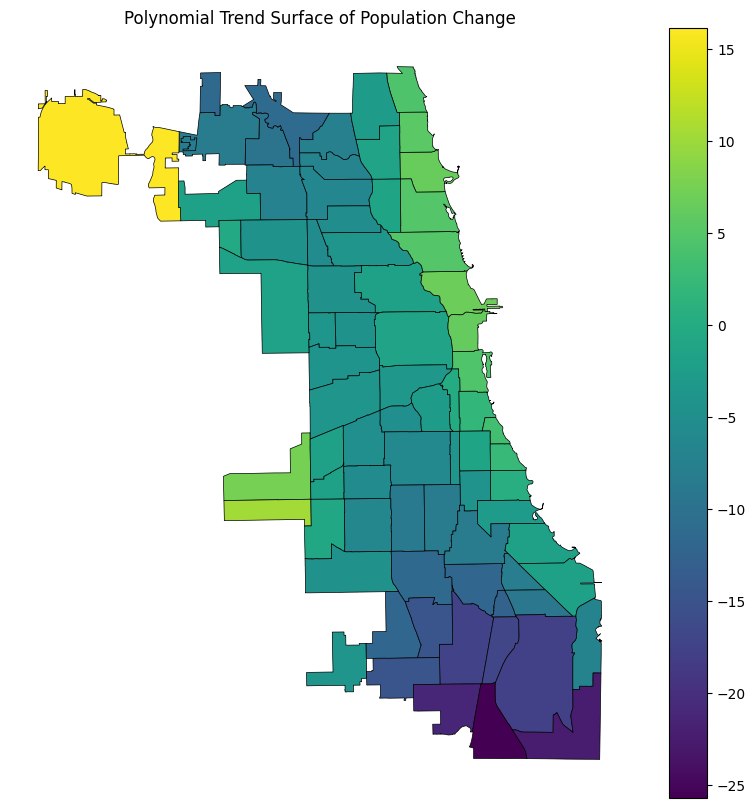

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_projected.plot(
    column="Trend_Prediction",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Polynomial Trend Surface of Population Change")
ax.set_axis_off()

plt.show()

In [20]:
features = gdf[
    [
        "POP2000",
        "POP2010",
        "POPCH",
        "POPPERCH"
    ]
].copy()

# Standardize the variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print(X_scaled.shape)

(77, 4)


In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

gdf["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print(gdf["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    42
3    23
1    10
2     2
Name: count, dtype: int64


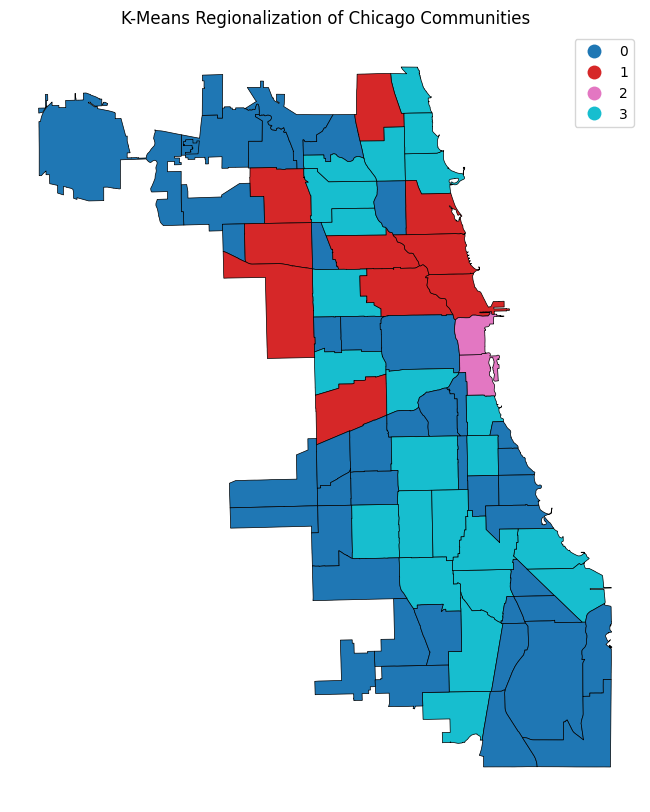

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="KMeans_Cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("K-Means Regionalization of Chicago Communities")
ax.set_axis_off()

plt.show()

In [23]:
# Use projected centroid coordinates
coordinates = gdf_projected[["X", "Y"]].values

# Standardize coordinates
coordinates_scaled = StandardScaler().fit_transform(coordinates)

dbscan = DBSCAN(
    eps=0.7,
    min_samples=4
)

gdf["DBSCAN_Cluster"] = dbscan.fit_predict(coordinates_scaled)

print(gdf["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    76
-1     1
Name: count, dtype: int64


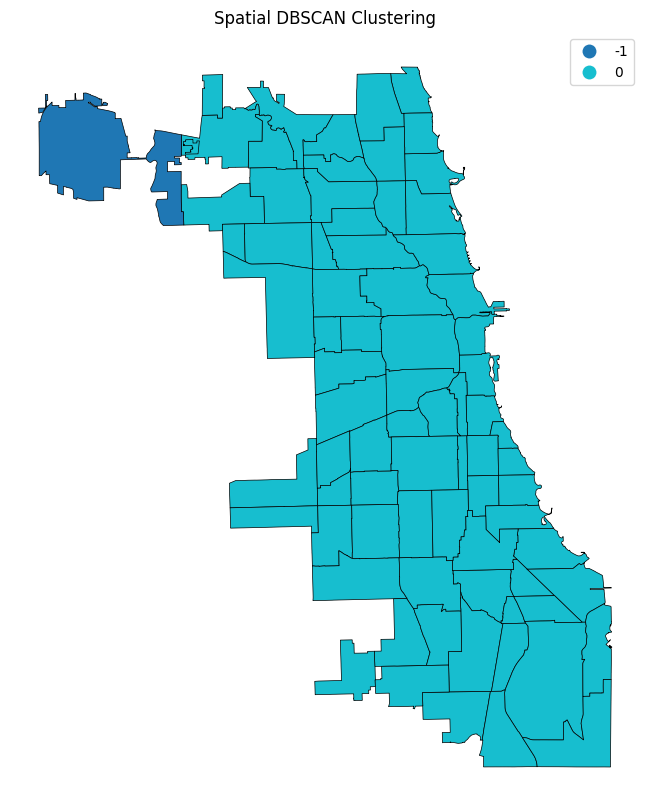

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="DBSCAN_Cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Spatial DBSCAN Clustering")
ax.set_axis_off()

plt.show()

In [25]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3
)

gdf["HDBSCAN_Cluster"] = clusterer.fit_predict(coordinates_scaled)

print(gdf["HDBSCAN_Cluster"].value_counts())

HDBSCAN_Cluster
-1    34
 1    26
 0    17
Name: count, dtype: int64


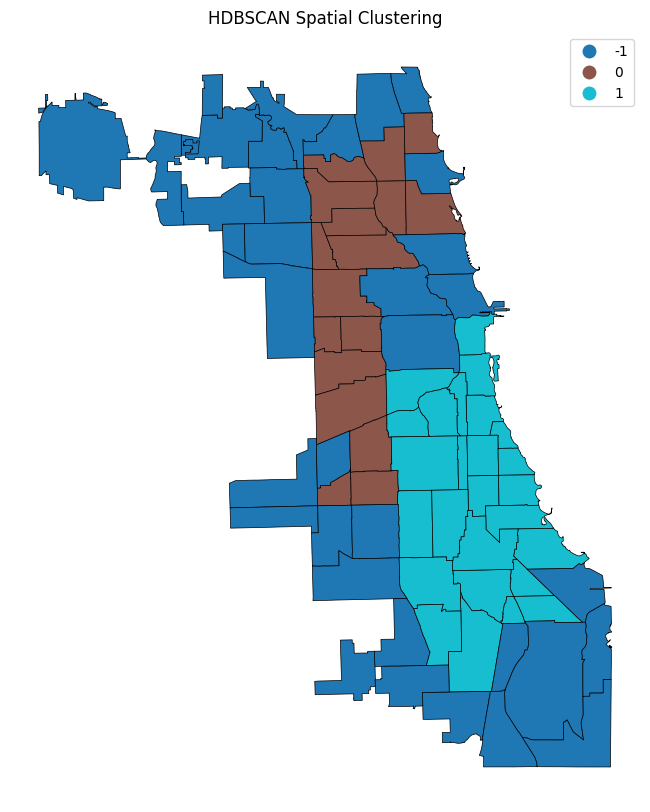

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="HDBSCAN_Cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("HDBSCAN Spatial Clustering")
ax.set_axis_off()

plt.show()

In [27]:
points = gdf_projected[["X", "Y"]].values

nearest = NearestNeighbors(
    n_neighbors=2
)

nearest.fit(points)

distances, indices = nearest.kneighbors(points)

# Distance to nearest OTHER point
nearest_distances = distances[:, 1]

observed_mean_distance = nearest_distances.mean()

print("Mean nearest-neighbor distance:",
      observed_mean_distance)

Mean nearest-neighbor distance: 2331.2653878739247


In [28]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(
    bandwidth=5000,
    kernel="gaussian"
)

kde.fit(points)

# Create grid
xmin, ymin = points.min(axis=0)
xmax, ymax = points.max(axis=0)

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 100),
    np.linspace(ymin, ymax, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]

log_density = kde.score_samples(grid)

density = np.exp(log_density).reshape(xx.shape)

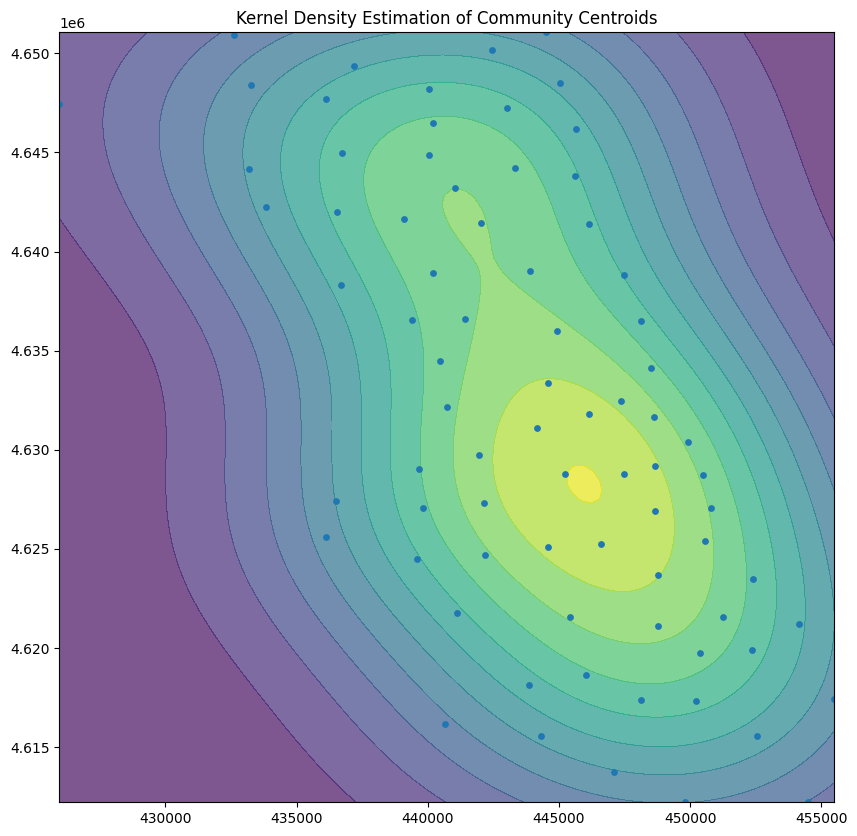

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.contourf(
    xx,
    yy,
    density,
    levels=15,
    alpha=0.7
)

ax.scatter(
    points[:, 0],
    points[:, 1],
    s=15
)

ax.set_title("Kernel Density Estimation of Community Centroids")

plt.show()

In [30]:
# Prepare dependent variable
gdf["log_POP2000"] = np.log1p(gdf["POP2000"])

# Dependent variable
y = gdf["POPPERCH"].values.reshape(-1, 1)

# Independent variable
X = gdf[["log_POP2000"]].values

print("Y shape:", y.shape)
print("X shape:", X.shape)

Y shape: (77, 1)
X shape: (77, 1)


In [31]:
lag_model = ML_Lag(
    y,
    X,
    w=w,
    name_y="Population_Percentage_Change",
    name_x=["Log_Population_2000"]
)

print(lag_model.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Population_Percentage_Change                Number of Observations:          77
Mean dependent var  :     -4.5198                Number of Variables   :           3
S.D. dependent var  :     20.5130                Degrees of Freedom    :          74
Pseudo R-squared    :      0.3634
Spatial Pseudo R-squared:  0.0057
Log likelihood      :   -330.3171
Sigma-square ML     :    282.1910                Akaike info criterion :     666.634
S.E of regression   :     16.7985                Schwarz criterion     :     673.666

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------

In [32]:
error_model = ML_Error(
    y,
    X,
    w=w,
    name_y="Population_Percentage_Change",
    name_x=["Log_Population_2000"]
)

print(error_model.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Population_Percentage_Change                Number of Observations:          77
Mean dependent var  :     -4.5198                Number of Variables   :           2
S.D. dependent var  :     20.5130                Degrees of Freedom    :          75
Pseudo R-squared    :      0.0392
Log likelihood      :   -328.9277
Sigma-square ML     :    269.6035                Akaike info criterion :     661.855
S.E of regression   :     16.4196                Schwarz criterion     :     666.543

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------------

In [33]:
print("========== SPATIAL LAG MODEL ==========")
print("AIC:", lag_model.aic)

print("\n========== SPATIAL ERROR MODEL ==========")
print("AIC:", error_model.aic)

if lag_model.aic < error_model.aic:
    print("\nSpatial Lag Model has lower AIC.")
else:
    print("\nSpatial Error Model has lower AIC.")

========== SPATIAL LAG MODEL ==========
AIC: 666.6342096897536

========== SPATIAL ERROR MODEL ==========
AIC: 661.8554346139172

Spatial Error Model has lower AIC.


In [34]:
result_columns = [
    "community",
    "POP2000",
    "POP2010",
    "POPCH",
    "POPPERCH",
    "Gi_ZScore",
    "Hotspot",
    "KMeans_Cluster",
    "DBSCAN_Cluster",
    "HDBSCAN_Cluster"
]

gdf[result_columns].head(20)

,community,POP2000,POP2010,POPCH,POPPERCH,Gi_ZScore,Hotspot,KMeans_Cluster,DBSCAN_Cluster,HDBSCAN_Cluster
0,DOUGLAS,26470,18238,-8232,-31.099358,-1.578712,Not Significant,3,0,1
1,OAKLAND,6110,5918,-192,-3.142390,0.682956,Not Significant,0,0,1
2,FULLER PARK,3420,2876,-544,-15.906433,0.361801,Not Significant,0,0,1
3,GRAND BOULEVARD,28006,21929,-6077,-21.698922,0.300720,Not Significant,3,0,1
4,KENWOOD,18363,17841,-522,-2.842673,0.463294,Not Significant,0,0,1
5,LINCOLN SQUARE,44574,39493,-5081,-11.399022,0.061263,Not Significant,3,0,0
6,WASHINGTON PARK,14146,11717,-2429,-17.170932,0.471861,Not Significant,0,0,1
7,HYDE PARK,29920,25681,-4239,-14.167781,0.344355,Not Significant,0,0,1
8,WOODLAWN,27086,25983,-1103,-4.072214,0.584607,Not Significant,0,0,1
9,ROGERS PARK,63484,54991,-8493,-13.378174,0.049739,Not Significant,3,0,-1


In [35]:
# Save results as GeoJSON
gdf.to_file(
    "chicago_spatial_analysis.geojson",
    driver="GeoJSON"
)

# Save attribute results as CSV
gdf.drop(columns="geometry").to_csv(
    "chicago_spatial_analysis_results.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [36]:
print("""
CONCLUSION:

The Chicago Community Population dataset was analyzed using advanced
geospatial techniques. Spatial weights were created using Queen contiguity
and Moran's I was used to measure spatial autocorrelation.

Polynomial regression was used for trend surface analysis to identify broad
geographical trends in population change. K-Means, DBSCAN and HDBSCAN were
used to identify spatial clusters and regional patterns.

Point pattern analysis was performed using nearest-neighbor distances and
Kernel Density Estimation. Finally, Spatial Lag and Spatial Error models
were developed to account for spatial dependence in population change.

These techniques demonstrate how spatial relationships and geographical
patterns can be incorporated into statistical and machine-learning models.
""")


CONCLUSION:

The Chicago Community Population dataset was analyzed using advanced
geospatial techniques. Spatial weights were created using Queen contiguity
and Moran's I was used to measure spatial autocorrelation.

Polynomial regression was used for trend surface analysis to identify broad
geographical trends in population change. K-Means, DBSCAN and HDBSCAN were
used to identify spatial clusters and regional patterns.

Point pattern analysis was performed using nearest-neighbor distances and
Kernel Density Estimation. Finally, Spatial Lag and Spatial Error models
were developed to account for spatial dependence in population change.

These techniques demonstrate how spatial relationships and geographical
patterns can be incorporated into statistical and machine-learning models.

